In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import colors
from copy import deepcopy

from rashomon import hasse, counter

%matplotlib inline

## Setup: Load Data

In [2]:
# Define profiles and best profile
profiles, profiles_map = hasse.enumerate_profiles(4)
profile_cols = [str(x) for x in profiles]
best_profile = (1, 0, 1, 0)
best_profile_idx = profiles_map[best_profile]
true_best_profile = str(best_profile)

print(f"True best profile: {true_best_profile}")
print(f"Profile index: {best_profile_idx}")
print(f"Total profiles: {len(profile_cols)}")

True best profile: (1, 0, 1, 0)
Profile index: 10
Total profiles: 16


In [8]:
# File configuration
fname_prefix = "4arms_"
fname_suffix = "_30_100.csv"

rashomon_fname = f"../Results/4arms/{fname_prefix}rashomon_30_50.csv"
blasso_fname = f"../Results/4arms/{fname_prefix}blasso_samples{fname_suffix}"
ssl_fname = f"../Results/4arms/{fname_prefix}ssl{fname_suffix}"
bootstrap_fname = f"../Results/4arms/{fname_prefix}bootstrap{fname_suffix}"
bootstrap_samples_fname = f"../Results/4arms/{fname_prefix}bootstrap_samples{fname_suffix}"

## Load All Methods

In [9]:
# Load Rashomon
rashomon_df = pd.read_csv(rashomon_fname).drop("Unnamed: 0", axis=1)
print(f"Rashomon: {len(rashomon_df)} models")

# Load Bayesian Lasso (samples)
blasso_df = pd.read_csv(blasso_fname).drop("Unnamed: 0", axis=1)
print(f"Bayesian Lasso: {len(blasso_df)} samples")

# Load Spike-Slab Lasso (samples)
ssl_df = pd.read_csv(ssl_fname).drop("Unnamed: 0", axis=1)
print(f"Spike-Slab Lasso: {len(ssl_df)} samples")

# Load Bootstrap (samples)
bootstrap_df = pd.read_csv(bootstrap_fname).drop("Unnamed: 0", axis=1)
bootstrap_samples_df = pd.read_csv(bootstrap_samples_fname).drop("Unnamed: 0", axis=1)
print(f"Bootstrap: {len(bootstrap_df)} summary, {len(bootstrap_samples_df)} samples")

Rashomon: 82994 models
Bayesian Lasso: 450000 samples
Bayesian Lasso: 450000 samples
Spike-Slab Lasso: 440000 samples
Spike-Slab Lasso: 440000 samples
Bootstrap: 100 summary, 100000 samples
Bootstrap: 100 summary, 100000 samples


In [10]:
# Quick inspection
print("\nBayesian Lasso columns:")
print(blasso_df.columns.tolist()[:20])

print("\nSSL columns:")
print(ssl_df.columns.tolist()[:20])

print("\nBootstrap samples columns:")
print(bootstrap_samples_df.columns.tolist()[:20])


Bayesian Lasso columns:
['n_per_pol', 'sim_num', 'sample_idx', 'neg_log_posterior', 'MSE', 'IOU', 'min_dosage', 'best_pol_diff', '(0, 0, 0, 0)', '(0, 0, 0, 1)', '(0, 0, 1, 0)', '(0, 0, 1, 1)', '(0, 1, 0, 0)', '(0, 1, 0, 1)', '(0, 1, 1, 0)', '(0, 1, 1, 1)', '(1, 0, 0, 0)', '(1, 0, 0, 1)', '(1, 0, 1, 0)', '(1, 0, 1, 1)']

SSL columns:
['n_per_pol', 'sim_num', 'sample_idx', 'neg_log_posterior', 'MSE', 'IOU', 'min_dosage', 'best_pol_diff', 'converged', 'max_rhat', 'IOU_coverage', 'min_dosage_coverage', 'mean_inclusion_prob', 'n_selected_features', '(0, 0, 0, 0)', '(0, 0, 0, 1)', '(0, 0, 1, 0)', '(0, 0, 1, 1)', '(0, 1, 0, 0)', '(0, 1, 0, 1)']

Bootstrap samples columns:
['n_per_pol', 'sim_num', 'sample_idx', 'penalized_loss', 'MSE', 'IOU', 'min_dosage', 'best_pol_diff', '(0, 0, 0, 0)', '(0, 0, 0, 1)', '(0, 0, 1, 0)', '(0, 0, 1, 1)', '(0, 1, 0, 0)', '(0, 1, 0, 1)', '(0, 1, 1, 0)', '(0, 1, 1, 1)', '(1, 0, 0, 0)', '(1, 0, 0, 1)', '(1, 0, 1, 0)', '(1, 0, 1, 1)']


## 1. HPD-Based Analysis (Fair Comparison to Rashomon)

For a fair comparison:
- **Rashomon**: Models within ε% of optimal (near-MAP region)
- **Bayesian methods**: Highest Posterior Density (HPD) region (e.g., 95% credible set)
- **Bootstrap**: Top models by penalized loss

This compares "high-quality model sets" across all methods.

In [27]:
def compute_frequency_inclusion(df, profile_col, group_cols=['n_per_pol', 'sim_num']):
    """
    Compute frequency-based inclusion rate.
    Returns: fraction of samples in each simulation that have the true best profile.
    """
    df_copy = df.copy()
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Fraction per simulation
    freq_per_sim = df_copy.groupby(group_cols)['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'frequency_inclusion'}, inplace=True)
    
    # Overall mean
    overall_freq = freq_per_sim['frequency_inclusion'].mean()
    
    return freq_per_sim, overall_freq

def compute_hpd_frequency(df, profile_col, credible_mass=0.95, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute frequency in Highest Posterior Density (HPD) region.
    This is the fair comparison to Rashomon's epsilon-ball.
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        credible_mass: Fraction of posterior mass to include (default 0.95)
        neg_log_posterior_col: Column with negative log posterior values
    
    Returns:
        freq_per_sim: DataFrame with HPD frequency per simulation
        overall_freq: Mean HPD frequency across simulations
        hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
    """
    df_copy = df.copy()
    
    # Convert to log posterior and normalize
    df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
    df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
        lambda x: x - x.max()
    )
    
    # Compute posterior weights
    df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
    df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
        lambda x: x / x.sum()
    )
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
    # Frequency within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
    overall_freq = freq_per_sim['hpd_frequency'].mean()
    
    return freq_per_sim, overall_freq, hpd_size_per_sim

def compute_top_k_frequency(df, profile_col, loss_col, k_fraction=0.95):
    """
    Compute frequency in top-K models by loss.
    For Bootstrap: use penalized loss to define "top models".
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        loss_col: Column with loss values (lower is better)
        k_fraction: Fraction of models to include (default 0.95)
    
    Returns:
        freq_per_sim: DataFrame with top-K frequency per simulation
        overall_freq: Mean top-K frequency across simulations
    """
    df_copy = df.copy()
    
    # Sort by loss within each simulation (ascending - lower loss is better)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', loss_col], ascending=[True, True, True])
    
    # Assign rank
    df_copy['rank'] = df_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    
    # Determine K for each simulation
    total_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    total_per_sim['k_threshold'] = (total_per_sim['total'] * k_fraction).astype(int)
    
    # Merge back
    df_copy = df_copy.merge(total_per_sim[['n_per_pol', 'sim_num', 'k_threshold']], on=['n_per_pol', 'sim_num'])
    
    # Keep only top-K
    top_k_samples = df_copy[df_copy['rank'] < df_copy['k_threshold']].copy()
    
    # Frequency within top-K
    top_k_samples['has_best_profile'] = (top_k_samples[profile_col] > 0).astype(int)
    freq_per_sim = top_k_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'topk_frequency'}, inplace=True)
    
    overall_freq = freq_per_sim['topk_frequency'].mean()
    
    return freq_per_sim, overall_freq

In [28]:
# Compute HPD-based inclusion (fair comparison to Rashomon)
credible_mass = 0.95

print(f"Computing HPD regions with {credible_mass*100}% posterior mass...\n")

# Rashomon: Already an epsilon-ball (keep as-is)
rashomon_freq, rashomon_freq_mean = compute_frequency_inclusion(
    rashomon_df, true_best_profile
)

# Bayesian Lasso: 95% HPD region
blasso_hpd_freq, blasso_hpd_freq_mean, blasso_hpd_size = compute_hpd_frequency(
    blasso_df, true_best_profile, credible_mass=credible_mass
)

# SSL: 95% HPD region
ssl_hpd_freq, ssl_hpd_freq_mean, ssl_hpd_size = compute_hpd_frequency(
    ssl_df, true_best_profile, credible_mass=credible_mass
)

# Bootstrap: Top 95% by penalized loss
bootstrap_topk_freq, bootstrap_topk_freq_mean = compute_top_k_frequency(
    bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=credible_mass
)

print("HPD/Top-K Inclusion Rates (Fair Comparison):")
print(f"  Rashomon (ε-ball):        {rashomon_freq_mean:.3f}")
print(f"  Bayesian Lasso (95% HPD): {blasso_hpd_freq_mean:.3f}")
print(f"  SSL (95% HPD):            {ssl_hpd_freq_mean:.3f}")
print(f"  Bootstrap (top 95%):      {bootstrap_topk_freq_mean:.3f}")

print(f"\nMean HPD/Top-K region sizes:")
print(f"  Bayesian Lasso: {blasso_hpd_size['hpd_size'].mean():.1f} samples")
print(f"  SSL:            {ssl_hpd_size['hpd_size'].mean():.1f} samples")

Computing HPD regions with 95.0% posterior mass...

HPD/Top-K Inclusion Rates (Fair Comparison):
  Rashomon (ε-ball):        0.473
  Bayesian Lasso (95% HPD): 0.231
  SSL (95% HPD):            0.500
  Bootstrap (top 95%):      0.468

Mean HPD/Top-K region sizes:
  Bayesian Lasso: 1.4 samples
  SSL:            1.0 samples
HPD/Top-K Inclusion Rates (Fair Comparison):
  Rashomon (ε-ball):        0.473
  Bayesian Lasso (95% HPD): 0.231
  SSL (95% HPD):            0.500
  Bootstrap (top 95%):      0.468

Mean HPD/Top-K region sizes:
  Bayesian Lasso: 1.4 samples
  SSL:            1.0 samples


## 2. Full Posterior Frequency (Exploration Breadth)

For MCMC methods, also compute frequency across ALL posterior samples to show how broadly the sampler explores.

In [29]:
# Compute full posterior frequency for MCMC methods

# Bayesian Lasso: all samples
blasso_full_freq, blasso_full_freq_mean = compute_frequency_inclusion(
    blasso_df, true_best_profile
)

# SSL: all samples
ssl_full_freq, ssl_full_freq_mean = compute_frequency_inclusion(
    ssl_df, true_best_profile
)

# Bootstrap: all samples
bootstrap_full_freq, bootstrap_full_freq_mean = compute_frequency_inclusion(
    bootstrap_samples_df, true_best_profile
)

print("Full Posterior/Sample Frequency (Exploration Breadth):")
print(f"  Bayesian Lasso:  {blasso_full_freq_mean:.3f}")
print(f"  SSL:             {ssl_full_freq_mean:.3f}")
print(f"  Bootstrap:       {bootstrap_full_freq_mean:.3f}")
print("\nNote: These are lower because they include low-probability regions.")

Full Posterior/Sample Frequency (Exploration Breadth):
  Bayesian Lasso:  0.157
  SSL:             0.103
  Bootstrap:       0.477

Note: These are lower because they include low-probability regions.


## 3. Posterior-Weighted Analysis (Bayesian Methods Only)

Weight samples by their posterior probability to get true Bayesian inference.

In [30]:
def compute_posterior_weighted_inclusion(df, profile_col, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute posterior-weighted inclusion probability.
    Returns: posterior probability that the true best profile is optimal.
    """
    df_copy = df.copy()
    
    # Convert to log posterior
    df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
    
    # Normalize within each simulation (subtract max for numerical stability)
    df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
        lambda x: x - x.max()
    )
    
    # Convert to probability weights
    df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
    df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
        lambda x: x / x.sum()
    )
    
    # Indicator for best profile
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Weighted sum per simulation
    weighted_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).apply(
        lambda x: (x['has_best_profile'] * x['posterior_weight']).sum()
    ).reset_index(name='posterior_inclusion')
    
    # Overall mean
    overall_weighted = weighted_per_sim['posterior_inclusion'].mean()
    
    return weighted_per_sim, overall_weighted, df_copy

In [31]:
# Compute posterior-weighted inclusion for Bayesian methods

# Bayesian Lasso
blasso_weighted, blasso_weighted_mean, blasso_with_weights = compute_posterior_weighted_inclusion(
    blasso_df, true_best_profile
)

# SSL
ssl_weighted, ssl_weighted_mean, ssl_with_weights = compute_posterior_weighted_inclusion(
    ssl_df, true_best_profile
)

print("Posterior-Weighted Inclusion Probabilities:")
print(f"  Bayesian Lasso:  {blasso_weighted_mean:.3f}")
print(f"  SSL:             {ssl_weighted_mean:.3f}")

Posterior-Weighted Inclusion Probabilities:
  Bayesian Lasso:  0.143
  SSL:             0.116


## 3. Posterior Concentration Analysis

Compare frequency-based (unweighted) vs posterior-weighted to understand how concentrated the posterior is.

In [32]:
def compute_effective_sample_size(df):
    """
    Compute effective sample size per simulation.
    ESS = 1 / sum(weights^2)
    Higher ESS = more diffuse, Lower ESS = more concentrated
    """
    ess_per_sim = df.groupby(['n_per_pol', 'sim_num']).apply(
        lambda x: 1 / (x['posterior_weight']**2).sum()
    ).reset_index(name='ESS')
    
    return ess_per_sim

In [33]:
# Compute ESS for Bayesian methods
blasso_ess = compute_effective_sample_size(blasso_with_weights)
ssl_ess = compute_effective_sample_size(ssl_with_weights)

# Get number of samples per simulation
n_samples_blasso = blasso_with_weights.groupby(['n_per_pol', 'sim_num']).size().iloc[0]
n_samples_ssl = ssl_with_weights.groupby(['n_per_pol', 'sim_num']).size().iloc[0]

print("Effective Sample Size (ESS):")
print(f"  Bayesian Lasso:  {blasso_ess['ESS'].mean():.1f} / {n_samples_blasso} ({blasso_ess['ESS'].mean()/n_samples_blasso:.3f})")
print(f"  SSL:             {ssl_ess['ESS'].mean():.1f} / {n_samples_ssl} ({ssl_ess['ESS'].mean()/n_samples_ssl:.3f})")
print("\nInterpretation:")
print("  ESS/N close to 1 → Diffuse posterior (samples roughly uniform)")
print("  ESS/N close to 0 → Concentrated posterior (few high-probability samples)")

Effective Sample Size (ESS):
  Bayesian Lasso:  1.1 / 4500 (0.000)
  SSL:             1.0 / 4400 (0.000)

Interpretation:
  ESS/N close to 1 → Diffuse posterior (samples roughly uniform)
  ESS/N close to 0 → Concentrated posterior (few high-probability samples)


In [34]:
def compute_posterior_entropy(df):
    """
    Compute Shannon entropy of posterior over profiles.
    Higher entropy = more uncertain/diffuse
    """
    def entropy_per_sim(group):
        # For each profile, compute weighted probability
        profile_probs = []
        for profile in profile_cols:
            if profile in group.columns:
                prob = (group[profile] * group['posterior_weight']).sum()
                profile_probs.append(prob)
        
        # Shannon entropy
        probs = np.array(profile_probs)
        probs = probs[probs > 0]  # Remove zeros
        entropy = -np.sum(probs * np.log(probs))
        
        return entropy
    
    entropy_per_sim = df.groupby(['n_per_pol', 'sim_num']).apply(
        entropy_per_sim
    ).reset_index(name='posterior_entropy')
    
    return entropy_per_sim

In [35]:
# Compute entropy
blasso_entropy = compute_posterior_entropy(blasso_with_weights)
ssl_entropy = compute_posterior_entropy(ssl_with_weights)

max_entropy = np.log(len(profile_cols))

print("Posterior Entropy:")
print(f"  Bayesian Lasso:  {blasso_entropy['posterior_entropy'].mean():.3f}")
print(f"  SSL:             {ssl_entropy['posterior_entropy'].mean():.3f}")
print(f"  Maximum (uniform): {max_entropy:.3f}")
print("\nInterpretation:")
print("  Entropy close to max → Uniform distribution over profiles")
print("  Entropy close to 0 → Concentrated on single profile")

Posterior Entropy:
  Bayesian Lasso:  0.063
  SSL:             0.007
  Maximum (uniform): 2.773

Interpretation:
  Entropy close to max → Uniform distribution over profiles
  Entropy close to 0 → Concentrated on single profile


## 4. Visualization: Four-Panel Comparison

In [36]:
# Combine all metrics for plotting
comparison_data = {
    'Method': ['Rashomon', 'Bayesian Lasso', 'SSL', 'Bootstrap'],
    'HPD_Frequency': [rashomon_freq_mean, blasso_hpd_freq_mean, ssl_hpd_freq_mean, bootstrap_topk_freq_mean],
    'Full_Frequency': [rashomon_freq_mean, blasso_full_freq_mean, ssl_full_freq_mean, bootstrap_full_freq_mean],
    'Posterior_Weighted': [np.nan, blasso_weighted_mean, ssl_weighted_mean, np.nan],
    'ESS_Ratio': [np.nan, blasso_ess['ESS'].mean()/n_samples_blasso, ssl_ess['ESS'].mean()/n_samples_ssl, np.nan],
    'Entropy': [np.nan, blasso_entropy['posterior_entropy'].mean(), ssl_entropy['posterior_entropy'].mean(), np.nan]
}
comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Method,HPD_Frequency,Full_Frequency,Posterior_Weighted,ESS_Ratio,Entropy
0,Rashomon,0.472639,0.472639,NaN,NaN,NaN
1,Bayesian Lasso,0.231481,0.156956,0.142524,0.000251,0.063305
2,SSL,0.500000,0.103009,0.115501,0.000231,0.007383
3,Bootstrap,0.468063,0.477200,NaN,NaN,NaN


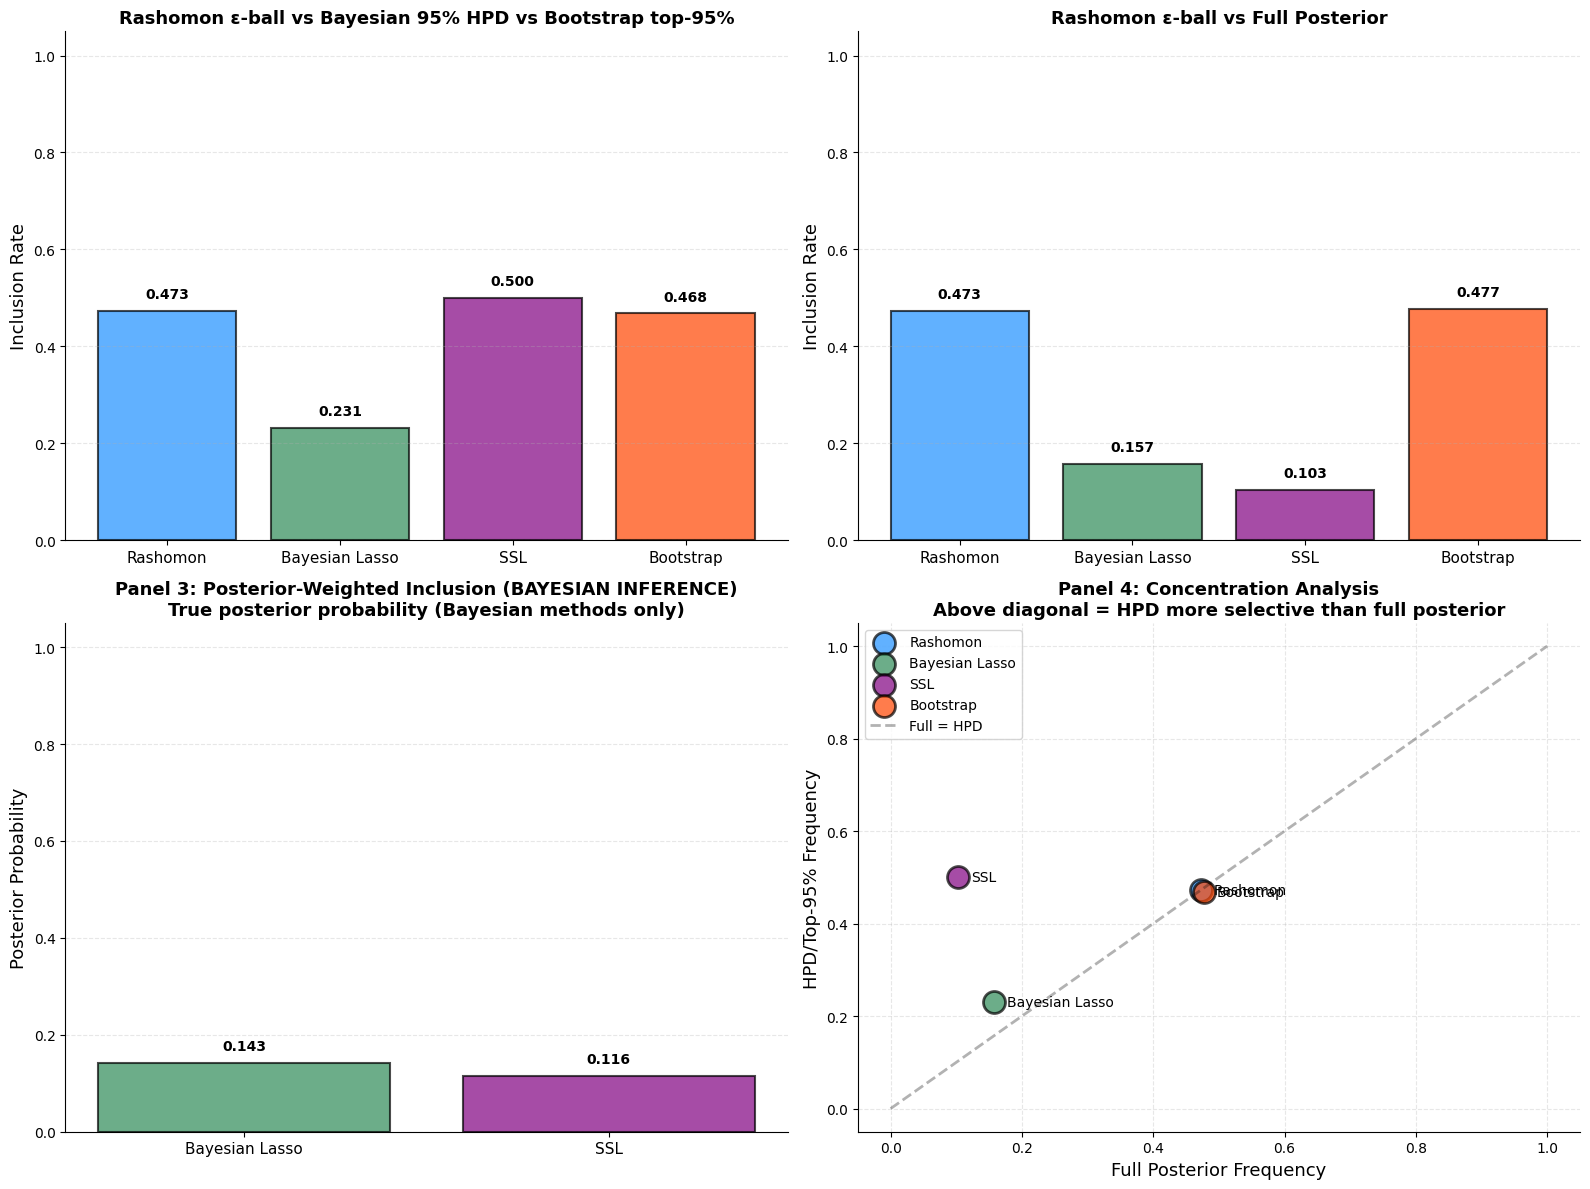

In [40]:
# Four-panel comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_methods = ['dodgerblue', 'seagreen', 'purple', 'orangered']

# Panel 1: HPD/Top-K Frequency (FAIR COMPARISON)
ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_df))
bars1 = ax1.bar(x_pos, comparison_df['HPD_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Method'], rotation=0, fontsize=11)
ax1.set_ylabel('Inclusion Rate', fontsize=13)
ax1.set_title('Rashomon ε-ball vs Bayesian 95% HPD vs Bootstrap top-95%', 
              fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 2: Full Posterior/Sample Frequency (EXPLORATION BREADTH)
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, comparison_df['Full_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Method'], rotation=0, fontsize=11)
ax2.set_ylabel('Inclusion Rate', fontsize=13)
ax2.set_title('Rashomon ε-ball vs Full Posterior', 
              fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 3: Posterior-weighted inclusion (Bayesian methods only)
ax3 = axes[1, 0]
bayesian_methods = comparison_df[comparison_df['Posterior_Weighted'].notna()]
x_pos_bayes = np.arange(len(bayesian_methods))
bars3 = ax3.bar(x_pos_bayes, bayesian_methods['Posterior_Weighted'], 
                color=[colors_methods[1], colors_methods[2]], alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_xticks(x_pos_bayes)
ax3.set_xticklabels(bayesian_methods['Method'], rotation=0, fontsize=11)
ax3.set_ylabel('Posterior Probability', fontsize=13)
ax3.set_title('Panel 3: Posterior-Weighted Inclusion (BAYESIAN INFERENCE)\nTrue posterior probability (Bayesian methods only)', 
              fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: HPD vs Full Frequency comparison (concentration)
ax4 = axes[1, 1]
for idx, row in comparison_df.iterrows():
    if not np.isnan(row['Full_Frequency']):
        ax4.scatter(row['Full_Frequency'], row['HPD_Frequency'], 
                   s=250, color=colors_methods[idx], alpha=0.7, 
                   edgecolor='black', linewidth=2, label=row['Method'])
        # Add method labels
        ax4.text(row['Full_Frequency'] + 0.02, row['HPD_Frequency'], row['Method'], 
                fontsize=10, va='center')

# Add diagonal reference line
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Full = HPD')
ax4.set_xlabel('Full Posterior Frequency', fontsize=13)
ax4.set_ylabel('HPD/Top-95% Frequency', fontsize=13)
ax4.set_title('Panel 4: Concentration Analysis\nAbove diagonal = HPD more selective than full posterior', 
              fontsize=13, fontweight='bold')
ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(-0.05, 1.05)
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(alpha=0.3, linestyle='--')
ax4.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/reff/posterior_comparison_four_panel.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Detailed Comparison: Distribution of Metrics Across Simulations

In [21]:
# Combine frequency and weighted metrics per simulation
blasso_comparison = blasso_freq.merge(blasso_weighted, on=['n_per_pol', 'sim_num'])
blasso_comparison['method'] = 'Bayesian Lasso'

ssl_comparison = ssl_freq.merge(ssl_weighted, on=['n_per_pol', 'sim_num'])
ssl_comparison['method'] = 'SSL'

bayesian_comparison = pd.concat([blasso_comparison, ssl_comparison], ignore_index=True)

bayesian_comparison.head()

,n_per_pol,sim_num,frequency_inclusion,posterior_inclusion,method
0,30,0,0.388444,2.417713e-01,Bayesian Lasso
1,30,1,0.094000,5.256933e-215,Bayesian Lasso
2,30,2,0.092667,1.849851e-191,Bayesian Lasso
3,30,3,0.106222,1.083915e-189,Bayesian Lasso
4,30,4,0.394444,7.228324e-06,Bayesian Lasso


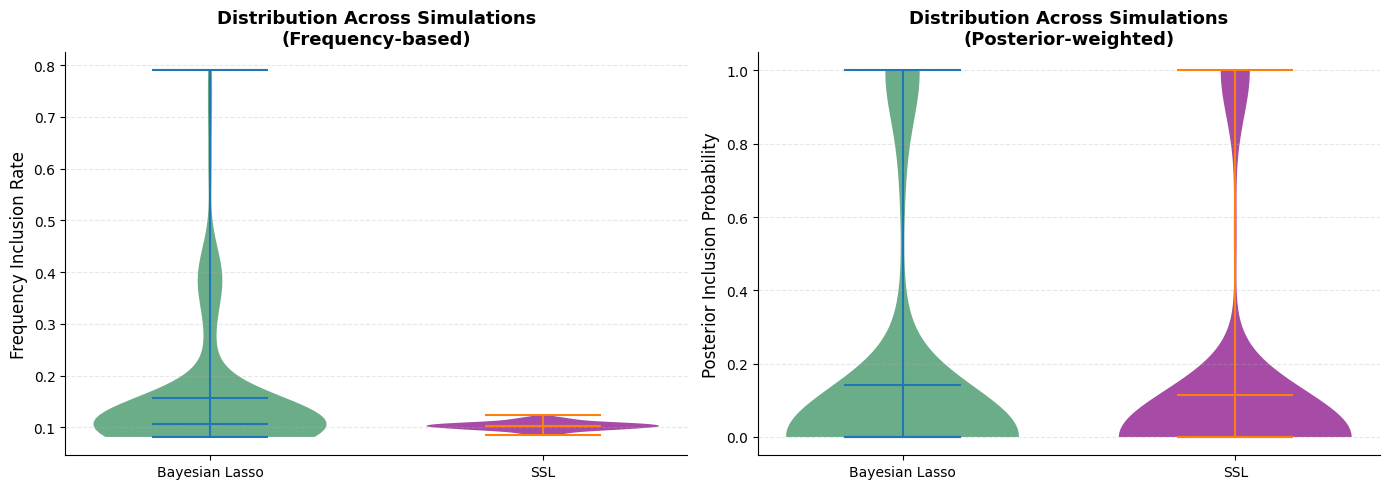

In [ ]:
# Violin plot: distribution of frequency vs posterior across simulations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency distribution
ax1 = axes[0]
for method, color in zip(['Bayesian Lasso', 'SSL'], [colors_methods[1], colors_methods[2]]):
    data = bayesian_comparison[bayesian_comparison['method'] == method]['frequency_inclusion']
    parts = ax1.violinplot([data], positions=[list(['Bayesian Lasso', 'SSL']).index(method)], 
                           widths=0.7, showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Bayesian Lasso', 'SSL'])
ax1.set_ylabel('Frequency Inclusion Rate', fontsize=12)
ax1.set_title('Distribution Across Simulations\n(Frequency-based)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Posterior-weighted distribution
ax2 = axes[1]
for method, color in zip(['Bayesian Lasso', 'SSL'], [colors_methods[1], colors_methods[2]]):
    data = bayesian_comparison[bayesian_comparison['method'] == method]['posterior_inclusion']
    parts = ax2.violinplot([data], positions=[list(['Bayesian Lasso', 'SSL']).index(method)], 
                           widths=0.7, showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Bayesian Lasso', 'SSL'])
ax2.set_ylabel('Posterior Inclusion Probability', fontsize=12)
ax2.set_title('Distribution Across Simulations\n(Posterior-weighted)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
# plt.savefig('../Figures/reff/posterior_comparison_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

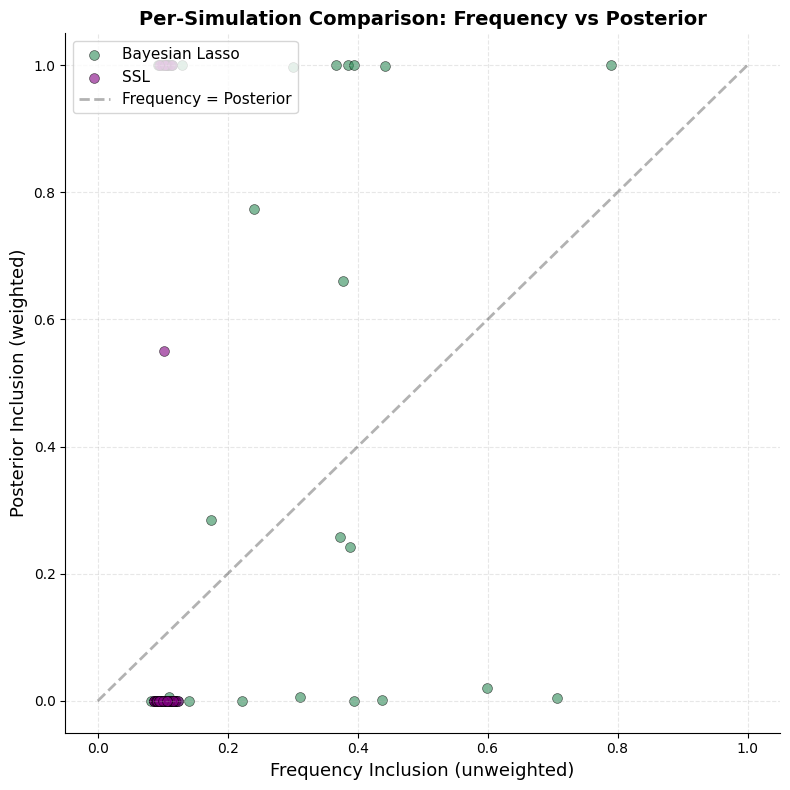

In [23]:
# Scatter plot: Frequency vs Posterior per simulation
fig, ax = plt.subplots(figsize=(8, 8))

for method, color in zip(['Bayesian Lasso', 'SSL'], [colors_methods[1], colors_methods[2]]):
    data = bayesian_comparison[bayesian_comparison['method'] == method]
    ax.scatter(data['frequency_inclusion'], data['posterior_inclusion'],
              s=50, alpha=0.6, color=color, edgecolor='black', linewidth=0.5,
              label=method)

# Diagonal reference
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Frequency = Posterior')

ax.set_xlabel('Frequency Inclusion (unweighted)', fontsize=13)
ax.set_ylabel('Posterior Inclusion (weighted)', fontsize=13)
ax.set_title('Per-Simulation Comparison: Frequency vs Posterior', fontsize=14, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
# plt.savefig('../Figures/reff/posterior_vs_frequency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Summary Statistics

In [ ]:
# Summary table
summary_stats = []

for method in ['Rashomon', 'Bayesian Lasso', 'SSL', 'Bootstrap']:
    row = {'Method': method}
    
    if method == 'Rashomon':
        row['HPD/Top-K Frequency (mean)'] = rashomon_freq_mean
        row['HPD/Top-K Frequency (std)'] = rashomon_freq['frequency_inclusion'].std()
        row['Full Frequency (mean)'] = rashomon_freq_mean
        row['Full Frequency (std)'] = rashomon_freq['frequency_inclusion'].std()
        row['Posterior (mean)'] = np.nan
        row['Posterior (std)'] = np.nan
        row['ESS Ratio'] = np.nan
        row['Entropy'] = np.nan
    elif method == 'Bayesian Lasso':
        row['HPD/Top-K Frequency (mean)'] = blasso_hpd_freq_mean
        row['HPD/Top-K Frequency (std)'] = blasso_hpd_freq['hpd_frequency'].std()
        row['Full Frequency (mean)'] = blasso_full_freq_mean
        row['Full Frequency (std)'] = blasso_full_freq['frequency_inclusion'].std()
        row['Posterior (mean)'] = blasso_weighted_mean
        row['Posterior (std)'] = blasso_weighted['posterior_inclusion'].std()
        row['ESS Ratio'] = blasso_ess['ESS'].mean() / n_samples_blasso
        row['Entropy'] = blasso_entropy['posterior_entropy'].mean()
    elif method == 'SSL':
        row['HPD/Top-K Frequency (mean)'] = ssl_hpd_freq_mean
        row['HPD/Top-K Frequency (std)'] = ssl_hpd_freq['hpd_frequency'].std()
        row['Full Frequency (mean)'] = ssl_full_freq_mean
        row['Full Frequency (std)'] = ssl_full_freq['frequency_inclusion'].std()
        row['Posterior (mean)'] = ssl_weighted_mean
        row['Posterior (std)'] = ssl_weighted['posterior_inclusion'].std()
        row['ESS Ratio'] = ssl_ess['ESS'].mean() / n_samples_ssl
        row['Entropy'] = ssl_entropy['posterior_entropy'].mean()
    elif method == 'Bootstrap':
        row['HPD/Top-K Frequency (mean)'] = bootstrap_topk_freq_mean
        row['HPD/Top-K Frequency (std)'] = bootstrap_topk_freq['topk_frequency'].std()
        row['Full Frequency (mean)'] = bootstrap_full_freq_mean
        row['Full Frequency (std)'] = bootstrap_full_freq['frequency_inclusion'].std()
        row['Posterior (mean)'] = np.nan
        row['Posterior (std)'] = np.nan
        row['ESS Ratio'] = np.nan
        row['Entropy'] = np.nan
    
    summary_stats.append(row)

summary_df = pd.DataFrame(summary_stats)
summary_df

,Method,Frequency (mean),Frequency (std),Posterior (mean),Posterior (std),ESS Ratio,Entropy
0,Rashomon,0.472639,0.477320,NaN,NaN,NaN,NaN
1,Bayesian Lasso,0.156956,0.130813,0.142524,0.336362,0.000251,0.063305
2,SSL,0.103009,0.007804,0.115501,0.317321,0.000231,0.007383
3,Bootstrap,0.477200,0.283279,NaN,NaN,NaN,NaN


In [25]:
# # Save summary to CSV
# summary_df.to_csv('../Results/4arms/posterior_comparison_summary.csv', index=False)
# print("Summary saved to ../Results/4arms/posterior_comparison_summary.csv")

## Key Insights

### Fair Comparison Framework

**Panel 1: HPD/Top-K Frequency (FAIR COMPARISON)**
- Compares "high-quality model sets" across all methods
- **Rashomon**: Models within ε% of optimal loss (ε-ball)
- **Bayesian Lasso & SSL**: 95% Highest Posterior Density (HPD) region
- **Bootstrap**: Top 95% by penalized loss
- **Interpretation**: "Among the best models, how often is the true profile optimal?"

**Panel 2: Full Posterior Frequency (EXPLORATION BREADTH)**
- Shows how broadly each method explores the model space
- Lower values indicate exploration of low-probability regions
- **Key insight**: MCMC methods explore more broadly than Rashomon's ε-ball
- **Interpretation**: "Across ALL sampled models, how often is the true profile optimal?"

**Panel 3: Posterior-Weighted Inclusion (BAYESIAN INFERENCE)**
- Only for Bayesian methods (Bayesian Lasso, SSL)
- Weights samples by posterior probability
- **Interpretation**: "What is the posterior probability that the true profile is optimal?"

**Panel 4: Concentration Analysis**
- Compares full posterior vs HPD frequencies
- **Above diagonal**: HPD is more selective (concentrated posterior)
- **On diagonal**: HPD similar to full posterior (diffuse posterior)
- **Interpretation**: "How concentrated is the posterior around high-probability models?"

### Metric Interpretations

**HPD/Top-K Frequency**:
- Higher → True profile often appears in best models
- Fair comparison across all methods

**Full Posterior Frequency**:
- Higher → MCMC finds true profile even in low-probability regions  
- Lower is expected (not a problem!)

**Posterior-Weighted Probability**:
- True Bayesian inference metric
- Accounts for model quality, not just presence

**ESS Ratio**:
- Close to 1 → Diffuse posterior (samples roughly uniform)
- Close to 0 → Concentrated posterior (few high-probability samples)

**Entropy**:
- Close to max (log(16) ≈ 2.77) → Uniform over profiles
- Close to 0 → Concentrated on single profile

### Why This Comparison is Fair

1. **Rashomon ε-ball** ≈ **Bayesian HPD** ≈ **Bootstrap top-K**
   - All represent "high-quality" model regions
   - Directly comparable across methods

2. **Full posterior frequency** shows exploration
   - Not meant for direct comparison with Rashomon
   - Shows how MCMC explores beyond high-probability regions

3. **Posterior-weighted** gives true Bayesian answer
   - Only applicable to Bayesian methods
   - Answers: "What should I believe?"